# SURROGATE CLASSES

## Bayesian Network

In [34]:
# packages
import pandas as pd
import numpy as np
import pgmpy  # cite this in paper
from pgmpy.estimators import HillClimbSearch, BicScore, BayesianEstimator
from pgmpy.models import BayesianNetwork
from pgmpy.inference import VariableElimination
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [36]:
## p2 ##

dsets = list(range(43,54))
size = 250

metrics = {
    "Intrusion": {
        "MSE": [],
        "r-squared": []
    },
    "Mass": {
        "MSE": [],
        "r-squared": []
    }
}

for dset in dsets:
    # load data
    data_raw = pd.read_csv(f"data_p2/{size}D/{size}d5_p2_seed_{dset}.csv")
    cols = ['x0', 'x1', 'x2', 'x3', 'x4', 'Intrusion', 'Mass']#, 'Penalized Mass']
    targets = ['Intrusion', 'Mass']
    features = ['x0', 'x1', 'x2', 'x3', 'x4']
    data = data_raw[cols]

    # discritize
    discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal')
    discritized_data = pd.DataFrame(
        discretizer.fit_transform(data),
        columns=data.columns
    ).astype(int)

    # split
    train_data, test_data = train_test_split(discritized_data, test_size=0.2, random_state=dset)

    # don't learn edges from target to target or from target to feature
    feature_to_target = [(x, target) for x in features for target in targets]
    target_to_feature_or_target = []
    for target in targets:
        for x in features:
            target_to_feature_or_target.append((target,x))

    target_to_feature_or_target.append(("Intrusion", "Mass"))
    target_to_feature_or_target.append(("Mass", "Intrusion"))


    # learn structure with HillClimbSearch
    hc = HillClimbSearch(train_data)#, scoring_method=BicScore(train_data))
    estimated_model = hc.estimate(
        # white_list=feature_to_target, 
        # black_list=target_to_feature_or_target, 
        scoring_method=BicScore(train_data)
    )

    # define and fit model
    bayesian = BayesianNetwork(estimated_model.edges())#, list(train_data.columns))
    bayesian.fit(train_data, estimator=BayesianEstimator)

    infer = VariableElimination(bayesian)

    nodes=set(bayesian.nodes())
    features_in_graph = [feature for feature in features if feature in nodes]

    predictions = {target: [] for target in targets}

    for _, row in test_data.iterrows():
        # evidence = row[features].to_dict() #{feature: row[feature] for feature in features_in_graph}
        evidence = {feature: row[feature] for feature in features_in_graph}
        for target in targets:
            query = infer.query([target], evidence=evidence)
            predictions[target].append(int(np.argmax(query.values)))

    predictions_df = pd.DataFrame(predictions, index=test_data.index)

    mse_intrusion = mean_squared_error(test_data['Intrusion'], predictions_df['Intrusion'])
    r2_intrusion = r2_score(test_data['Intrusion'], predictions_df['Intrusion'])
    mse_mass = mean_squared_error(test_data['Mass'], predictions_df['Mass'])
    r2_mass = r2_score(test_data['Mass'], predictions_df['Mass'])

    # print("=== Bayesian Network on problem 2 - threepointbending ===")
    # print(f"Intrusion | MSE: {mse_intrusion}  r-squared: {r2_intrusion}")
    # print(f"Mass | MSE: {mse_mass}  r-squared: {r2_mass}")
    metrics['Intrusion']["MSE"].append(mse_intrusion)
    metrics['Intrusion']["r-squared"].append(r2_intrusion)
    metrics['Mass']["MSE"].append(mse_mass)
    metrics['Mass']["r-squared"].append(r2_mass)

print(f"====================== Bayesian Network on problem 2 (threepoint bending) with {len(dsets)} cv folds ======================")
print(f"Intrusion | mean MSE: {np.mean(metrics['Intrusion']['MSE'])}   mean r-squared: {np.mean(metrics['Intrusion']['r-squared'])}")
print(f"Mass | mean MSE: {np.mean(metrics['Mass']['MSE'])}   mean r-squared: {np.mean(metrics['Mass']['r-squared'])}")

/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


  0%|          | 0/1000000 [00:00<?, ?it/s]

/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


  0%|          | 0/1000000 [00:00<?, ?it/s]

/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


...

/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


  0%|          | 0/1000000 [00:00<?, ?it/s]

/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


  0%|          | 0/1000000 [00:00<?, ?it/s]

====================== Bayesian Network on problem 2 (threepoint bending) with 11 cv folds ======================
Intrusion | mean MSE: 0.5490909090909092   mean r-squared: 0.7267380403170994
Mass | mean MSE: 0.5432727272727272   mean r-squared: 0.7286712766219938


In [ ]:
## p1 ##

dsets = list(range(43,53))
size = 250

metrics = {
    "Intrusion": {
        "MSE": [],
        "r-squared": []
    },
    "SEA": {
        "MSE": [],
        "r-squared": []
    }
}

for dset in dsets:
    # load data
    data_raw = pd.read_csv(f"data_p1/{size}D/{size}d5_p1_seed_{dset}.csv")
    cols = ['x0', 'x1', 'x2', 'x3', 'x4', 'Intrusion', 'SEA']#, 'Penalized SEA']
    targets = ['Intrusion', 'SEA']
    features = ['x0', 'x1', 'x2', 'x3', 'x4']
    data = data_raw[cols]

    # discritize
    discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal')
    discritized_data = pd.DataFrame(
        discretizer.fit_transform(data),
        columns=data.columns
    ).astype(int)

    # split
    train_data, test_data = train_test_split(discritized_data, test_size=0.2, random_state=dset)

    # don't learn edges from target to target or from target to feature
    feature_to_target = [(x, target) for x in features for target in targets]
    target_to_feature_or_target = []
    for target in targets:
        for x in features:
            target_to_feature_or_target.append((target,x))

    target_to_feature_or_target.append(("Intrusion", "SEA"))
    target_to_feature_or_target.append(("SEA", "Intrusion"))


    # learn structure with HillClimbSearch
    hc = HillClimbSearch(train_data)#, scoring_method=BicScore(train_data))
    estimated_model = hc.estimate(
        white_list=feature_to_target, 
        black_list=target_to_feature_or_target, 
        scoring_method=BicScore(train_data)
    )


    # define and fit model
    bayesian = BayesianNetwork(estimated_model.edges())#, list(train_data.columns))
    bayesian.fit(train_data, estimator=BayesianEstimator)

    infer = VariableElimination(bayesian)

    nodes=set(bayesian.nodes())
    features_in_graph = [feature for feature in features if feature in nodes]

    predictions = {target: [] for target in targets}

    for _, row in test_data.iterrows():
        evidence = {feature: row[feature] for feature in features_in_graph} #row[features].to_dict() #{feature: row[feature] for feature in features_in_graph}
        for target in targets:
            query = infer.query([target], evidence=evidence)
            predictions[target].append(int(np.argmax(query.values)))

    predictions_df = pd.DataFrame(predictions, index=test_data.index)

    mse_intrusion = mean_squared_error(test_data['Intrusion'], predictions_df['Intrusion'])
    r2_intrusion = r2_score(test_data['Intrusion'], predictions_df['Intrusion'])
    mse_sea = mean_squared_error(test_data['SEA'], predictions_df['SEA'])
    r2_sea = r2_score(test_data['SEA'], predictions_df['SEA'])

    print("=== Bayesian Network on problem 1 - starbox ===")
    print(f"Intrusion | MSE: {mse_intrusion}  r-squared: {r2_intrusion}")
    print(f"SEA | MSE: {mse_sea}  r-squared: {r2_sea}")

    metrics['Intrusion']["MSE"].append(mse_intrusion)
    metrics['Intrusion']["r-squared"].append(r2_intrusion)
    metrics['SEA']["MSE"].append(mse_mass)
    metrics['SEA']["r-squared"].append(r2_mass)

print(f"====================== Bayesian Network on problem 1 (starbox) with {len(dsets)} cv folds ======================")
print(f"Intrusion | mean MSE: {np.mean(metrics['Intrusion']['MSE'])}   mean r-squared: {np.mean(metrics['Intrusion']['r-squared'])}")
print(f"SEA | mean MSE: {np.mean(metrics['SEA']['MSE'])}   mean r-squared: {np.mean(metrics['SEA']['r-squared'])}")

/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


  0%|          | 0/1000000 [00:00<?, ?it/s]

=== Bayesian Network on problem 1 - starbox ===
Intrusion | MSE: 0.2  r-squared: 0.8959451922516628
SEA | MSE: 0.376  r-squared: 0.8069672501458014


/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


  0%|          | 0/1000000 [00:00<?, ?it/s]

...

  0%|          | 0/1000000 [00:00<?, ?it/s]

=== Bayesian Network on problem 1 - starbox ===
Intrusion | MSE: 0.18  r-squared: 0.9068253534424926
SEA | MSE: 0.336  r-squared: 0.8232382748055621


/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


  0%|          | 0/1000000 [00:00<?, ?it/s]

=== Bayesian Network on problem 1 - starbox ===
Intrusion | MSE: 0.204  r-squared: 0.8986075435987563
SEA | MSE: 0.372  r-squared: 0.8049905640595513
====================== Bayesian Network on problem 1 (starbox) with 10 cv folds ======================
Intrusion | mean MSE: 0.2112   mean r-squared: 0.894245801370228
SEA | mean MSE: 0.508   mean r-squared: 0.7449061576038052


In [ ]:
## p3 ##

# load data
data_raw = pd.read_csv(".csv")
cols = ['x0', 'x1', 'x2', 'x3', 'x4', 'Intrusion', 'LU']#, 'Penalized SEA']
targets = ['Intrusion', 'LU']
features = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14']
data = data_raw[cols]

# discritize
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal')
discritized_data = pd.DataFrame(
    discretizer.fit_transform(data),
    columns=data.columns
).astype(int)

# split
train_data, test_data = train_test_split(discritized_data, test_size=0.2, random_state=1)

# don't learn edges from target to target or from target to feature
feature_to_target = [(x, target) for x in features for target in targets]
target_to_feature_or_target = []
for target in targets:
    for x in features:
        target_to_feature_or_target.append((target,x))

target_to_feature_or_target.append(("Intrusion", "LU"))
target_to_feature_or_target.append(("LU", "Intrusion"))


# learn structure with HillClimbSearch
hc = HillClimbSearch(train_data)#, scoring_method=BicScore(train_data))
estimated_model = hc.estimate(
    # white_list=feature_to_target, 
    # black_list=target_to_feature_or_target, 
    scoring_method=BicScore(train_data)
)


# define and fit model
bayesian = BayesianNetwork(estimated_model.edges())#, list(train_data.columns))
bayesian.fit(train_data, estimator=BayesianEstimator)

infer = VariableElimination(bayesian)

# nodes=set(bayesian.nodes())
# features_in_graph = [feature for feature in features if feature in nodes]

predictions = {target: [] for target in targets}

for _, row in test_data.iterrows():
    evidence = row[features].to_dict() #{feature: row[feature] for feature in features_in_graph}
    for target in targets:
        query = infer.query([target], evidence=evidence)
        predictions[target].append(int(np.argmax(query.values)))

predictions_df = pd.DataFrame(predictions, index=test_data.index)

mse_intrusion = mean_squared_error(test_data['Intrusion'], predictions_df['Intrusion'])
r2_intrusion = r2_score(test_data['Intrusion'], predictions_df['Intrusion'])
mse_lu = mean_squared_error(test_data['LU'], predictions_df['LU'])
r2_lu = r2_score(test_data['LU'], predictions_df['LU'])

print("=== Bayesian Network on problem 1 - starbox ===")
print(f"Intrusion | MSE: {mse_intrusion}  r-squared: {r2_intrusion}")
print(f"SEA | MSE: {mse_sea}  r-squared: {r2_sea}")

FileNotFoundError: [Errno 2] No such file or directory: '.csv'

## Gaussian Process

In [28]:
# packages + data
import gpytorch #cite
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [47]:
## p2 ##

dsets = list(range(43,54))
size = 250

metrics = {
    "Intrusion": {
        "MSE": [],
        "r-squared": []
    },
    "Mass": {
        "MSE": [],
        "r-squared": []
    }
}

for dset in dsets:
    # get data from csv
    # data = pd.read_csv("250d5_p1_seed_43.csv")
    data = pd.read_csv(f"data_p2/250D/{size}d5_p2_seed_{dset}.csv")
    # get data from csv
    # data = pd.read_csv("250d5_p2_seed_43.csv")
    # data = pd.read_csv("30d5_p2.csv")
    X = data[['x0', 'x1', 'x2', 'x3', 'x4']]
    # y_intrusion = data['y0']
    # y_mass = data['y1']
    # y_penalized_mass = data['y2']
    y_intrusion = data['Intrusion']
    y_mass = data['Mass']
    y_penalized_mass = data['Penalized Mass']

    X_intrusion_train, X_intrusion_test, y_intrusion_train, y_intrusion_test = train_test_split(X, y_intrusion, test_size=0.2, random_state=dset)
    X_mass_train, X_mass_test, y_mass_train, y_mass_test = train_test_split(X, y_mass, test_size=0.2, random_state=dset)
    X_penalized_mass_train,X_penalized_mass_test,y_penalized_mass_train, y_penalized_mass_test = train_test_split(X, y_penalized_mass, test_size=0.2, random_state=dset)

    scaler_intrusion = StandardScaler()
    scaler_mass = StandardScaler()
    scaler_penalized_mass = StandardScaler()

    X_intrusion_train = scaler_intrusion.fit_transform(X_intrusion_train)
    X_intrusion_test = scaler_intrusion.transform(X_intrusion_test)
    X_mass_train = scaler_mass.fit_transform(X_mass_train)
    X_mass_test = scaler_mass.transform(X_mass_test)
    X_penalized_mass_train = scaler_penalized_mass.fit_transform(X_penalized_mass_train)
    X_penalized_mass_test = scaler_penalized_mass.transform(X_penalized_mass_test)


    X_intrusion_train = torch.tensor(X_intrusion_train, dtype=torch.float32)
    X_intrusion_test = torch.tensor(X_intrusion_test, dtype=torch.float32)
    y_intrusion_train = torch.tensor(y_intrusion_train.values, dtype=torch.float32)
    y_intrusion_test = torch.tensor(y_intrusion_test.values, dtype=torch.float32)

    X_mass_train = torch.tensor(X_mass_train, dtype=torch.float32)
    X_mass_test = torch.tensor(X_mass_test, dtype=torch.float32)
    y_mass_train = torch.tensor(y_mass_train.values, dtype=torch.float32)
    y_mass_test = torch.tensor(y_mass_test.values, dtype=torch.float32)

    X_penalized_mass_train = torch.tensor(X_penalized_mass_train, dtype=torch.float32)
    X_penalized_mass_test = torch.tensor(X_penalized_mass_test, dtype=torch.float32)
    y_penalized_mass_train = torch.tensor(y_penalized_mass_train.values, dtype=torch.float32)
    y_penalized_mass_test = torch.tensor(y_penalized_mass_test.values, dtype=torch.float32)


    # define model class
    class GPRegressionModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super(GPRegressionModel, self).__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

        def forward(self,x):
            mean_x = self.mean_module(x)
            covar_x = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean_x,covar_x)
        

    # initialize models
    likelihood_intrusion = gpytorch.likelihoods.GaussianLikelihood()
    gp_intrusion = GPRegressionModel(X_intrusion_train, y_intrusion_train, likelihood_intrusion)

    likelihood_mass = gpytorch.likelihoods.GaussianLikelihood()
    gp_mass = GPRegressionModel(X_mass_train, y_mass_train, likelihood_mass)

    likelihood_penalized_mass = gpytorch.likelihoods.GaussianLikelihood()
    gp_penalized_mass = GPRegressionModel(X_penalized_mass_train, y_penalized_mass_train, likelihood_penalized_mass)


    print(f"fitting on dset {dset}")
    # fit the models
    gp_intrusion.train()
    likelihood_intrusion.train()

    optimizer = torch.optim.Adam(gp_intrusion.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_intrusion, gp_intrusion)

    for i in range(100):
        optimizer.zero_grad()
        output = gp_intrusion(X_intrusion_train)
        loss = -mll(output, y_intrusion_train)
        loss.backward()
        optimizer.step()

        # print(f"training intrusion model: {i}/100 epochs")
    print("trained intrusion gp")

    gp_mass.train()
    likelihood_mass.train()

    optimizer = torch.optim.Adam(gp_mass.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_mass, gp_mass)

    for i in range(100):
        optimizer.zero_grad()
        output = gp_mass(X_mass_train)
        loss = -mll(output, y_mass_train)
        loss.backward()
        optimizer.step()

        # print(f"training intrusion model: {i}/100 epochs")
    print("trained intrusion gp")

    gp_penalized_mass.train()
    likelihood_penalized_mass.train()

    optimizer = torch.optim.Adam(gp_penalized_mass.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_penalized_mass, gp_penalized_mass)

    for i in range(100):
        optimizer.zero_grad()
        output = gp_penalized_mass(X_penalized_mass_train)
        loss = -mll(output, y_penalized_mass_train)
        loss.backward()
        optimizer.step()

        # print(f"training penalized mass model: {i}/100 epochs")
    print("trained penalized mass gp")

    gp_intrusion.eval()
    likelihood_intrusion.eval()

    gp_mass.eval()
    likelihood_mass.eval()

    gp_penalized_mass.eval()
    likelihood_penalized_mass.eval()

    #TODO: keep track of feature importance

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        intrusion_predictions = likelihood_intrusion(gp_intrusion(X_intrusion_test))
        gp_intrusion_predictions = intrusion_predictions.mean

        mass_predictions = likelihood_mass(gp_mass(X_mass_test))
        gp_mass_predictions = mass_predictions.mean

        penalized_mass_predictions = likelihood_penalized_mass(gp_penalized_mass(X_penalized_mass_test))
        gp_penalized_mass_predictions = penalized_mass_predictions.mean

    mse_intrusion = mean_squared_error(y_intrusion_test, gp_intrusion_predictions)
    r2_intrusion = r2_score(y_intrusion_test, gp_intrusion_predictions)
    mse_mass = mean_squared_error(y_mass_test,gp_mass_predictions)
    r2_mass = r2_score(y_mass_test, gp_mass_predictions)
    mse_penalized_mass = mean_squared_error(y_penalized_mass_test, gp_penalized_mass_predictions)
    r2_penalized_mass = r2_score(y_penalized_mass_test, gp_penalized_mass_predictions)


    # print("=== Gaussian Process on problem 2 - threepointbending ===")
    # print(f"Inrusion | MSE: {mse_intrusion}   r-squared: {r2_intrusion}")
    # print(f"Mass | MSE: {mse_mass}   r-squared: {r2_mass}")
    # print(f"Penalized Mass | MSE: {mse_penalized_mass}   r-squared: {r2_penalized_mass}")
    metrics['Intrusion']["MSE"].append(mse_intrusion)
    metrics['Intrusion']["r-squared"].append(r2_intrusion)
    metrics['Mass']["MSE"].append(mse_mass)
    metrics['Mass']["r-squared"].append(r2_mass)

print(f"====================== XGBoost on problem 2 (threepointbending) with {len(dsets)} cv folds ======================")
print(f"Intrusion | mean MSE: {np.mean(metrics['Intrusion']['MSE'])}   mean r-squared: {np.mean(metrics['Intrusion']['r-squared'])}")
print(f"Mass | mean MSE: {np.mean(metrics['Mass']['MSE'])}   mean r-squared: {np.mean(metrics['Mass']['r-squared'])}")
                                                                                

fitting on dset 43
trained intrusion gp
trained intrusion gp
trained penalized mass gp
fitting on dset 44
trained intrusion gp
trained intrusion gp
trained penalized mass gp
fitting on dset 45
trained intrusion gp
trained intrusion gp
trained penalized mass gp
fitting on dset 46
trained intrusion gp
trained intrusion gp
trained penalized mass gp
fitting on dset 47
trained intrusion gp
trained intrusion gp
trained penalized mass gp
fitting on dset 48
trained intrusion gp
trained intrusion gp
trained penalized mass gp
fitting on dset 49
trained intrusion gp
trained intrusion gp
trained penalized mass gp
fitting on dset 50
trained intrusion gp
trained intrusion gp
trained penalized mass gp
fitting on dset 51
trained intrusion gp
trained intrusion gp
trained penalized mass gp
fitting on dset 52
trained intrusion gp
trained intrusion gp
trained penalized mass gp
fitting on dset 53
trained intrusion gp
trained intrusion gp
trained penalized mass gp
====================== XGBoost on problem 2

In [ ]:
## p1 ##

dsets = list(range(43,53))
size = 250

metrics = {
    "Intrusion": {
        "MSE": [],
        "r-squared": []
    },
    "SEA": {
        "MSE": [],
        "r-squared": []
    }
}

for dset in dsets:
    # get data from csv
    # data = pd.read_csv("250d5_p1_seed_43.csv")
    data = pd.read_csv(f"data_p1/250D/{size}d5_p1_seed_{dset}.csv")

    # data = pd.read_csv("30d5_p1.csv")  # TODO: make this
    X = data[['x0', 'x1', 'x2', 'x3', 'x4']]
    # y_intrusion = data['y0']
    # y_sea = data['y1']
    # y_penalized_sea = data['y2']

    y_intrusion = data['Intrusion']
    y_sea= data['SEA']
    y_penalized_sea = data['Penalized SEA']

    X_intrusion_train, X_intrusion_test, y_intrusion_train, y_intrusion_test = train_test_split(X, y_intrusion, test_size=0.2, random_state=dset)
    X_sea_train, X_sea_test, y_sea_train, y_sea_test = train_test_split(X, y_sea, test_size=0.2, random_state=dset)
    X_penalized_sea_train,X_penalized_sea_test,y_penalized_sea_train, y_penalized_sea_test = train_test_split(X, y_penalized_sea, test_size=0.2, random_state=dset)

    scaler_intrusion = StandardScaler()
    scaler_sea = StandardScaler()
    scaler_penalized_sea = StandardScaler()

    X_intrusion_train = scaler_intrusion.fit_transform(X_intrusion_train)
    X_intrusion_test = scaler_intrusion.transform(X_intrusion_test)
    X_sea_train = scaler_sea.fit_transform(X_sea_train)
    X_sea_test = scaler_sea.transform(X_sea_test)
    X_penalized_sea_train = scaler_penalized_sea.fit_transform(X_penalized_sea_train)
    X_penalized_sea_test = scaler_penalized_sea.transform(X_penalized_sea_test)


    X_intrusion_train = torch.tensor(X_intrusion_train, dtype=torch.float32)
    X_intrusion_test = torch.tensor(X_intrusion_test, dtype=torch.float32)
    y_intrusion_train = torch.tensor(y_intrusion_train.values, dtype=torch.float32)
    y_intrusion_test = torch.tensor(y_intrusion_test.values, dtype=torch.float32)

    X_sea_train = torch.tensor(X_sea_train, dtype=torch.float32)
    X_sea_test = torch.tensor(X_sea_test, dtype=torch.float32)
    y_sea_train = torch.tensor(y_sea_train.values, dtype=torch.float32)
    y_sea_test = torch.tensor(y_sea_test.values, dtype=torch.float32)

    X_penalized_sea_train = torch.tensor(X_penalized_sea_train, dtype=torch.float32)
    X_penalized_sea_test = torch.tensor(X_penalized_sea_test, dtype=torch.float32)
    y_penalized_sea_train = torch.tensor(y_penalized_sea_train.values, dtype=torch.float32)
    y_penalized_sea_test = torch.tensor(y_penalized_sea_test.values, dtype=torch.float32)


    # define model class
    class GPRegressionModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super(GPRegressionModel, self).__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

        def forward(self,x):
            mean_x = self.mean_module(x)
            covar_x = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean_x,covar_x)
        

    # initialize models
    likelihood_intrusion = gpytorch.likelihoods.GaussianLikelihood()
    gp_intrusion = GPRegressionModel(X_intrusion_train, y_intrusion_train, likelihood_intrusion)

    likelihood_sea = gpytorch.likelihoods.GaussianLikelihood()
    gp_sea = GPRegressionModel(X_sea_train, y_sea_train, likelihood_sea)

    likelihood_penalized_sea = gpytorch.likelihoods.GaussianLikelihood()
    gp_penalized_sea = GPRegressionModel(X_penalized_sea_train, y_penalized_sea_train, likelihood_penalized_sea)

    print(f"fitting on set {dset}")

    # fit the models
    gp_intrusion.train()
    likelihood_intrusion.train()

    optimizer = torch.optim.Adam(gp_intrusion.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_intrusion, gp_intrusion)

    for i in range(100):
        optimizer.zero_grad()
        output = gp_intrusion(X_intrusion_train)
        loss = -mll(output, y_intrusion_train)
        loss.backward()
        optimizer.step()

        # print(f"training intrusion model: {i}/100 epochs")
    print("trained intrusion gp")

    gp_sea.train()
    likelihood_sea.train()

    optimizer = torch.optim.Adam(gp_sea.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_sea, gp_sea)

    for i in range(100):
        optimizer.zero_grad()
        output = gp_sea(X_sea_train)
        loss = -mll(output, y_sea_train)
        loss.backward()
        optimizer.step()

        # print(f"training intrusion model: {i}/100 epochs")
    print("trained sea gp")

    gp_penalized_sea.train()
    likelihood_penalized_sea.train()

    optimizer = torch.optim.Adam(gp_penalized_sea.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_penalized_sea, gp_penalized_sea)

    for i in range(100):
        optimizer.zero_grad()
        output = gp_penalized_mass(X_penalized_sea_train)
        loss = -mll(output, y_penalized_sea_train)
        loss.backward()
        optimizer.step()

        # print(f"training penalized mass model: {i}/100 epochs")
    print("trained penalized sea gp")

    gp_intrusion.eval()
    likelihood_intrusion.eval()

    gp_sea.eval()
    likelihood_sea.eval()

    gp_penalized_sea.eval()
    likelihood_penalized_sea.eval()

    #TODO: keep track of feature importance

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        intrusion_predictions = likelihood_intrusion(gp_intrusion(X_intrusion_test))
        gp_intrusion_predictions = intrusion_predictions.mean

        sea_predictions = likelihood_mass(gp_sea(X_sea_test))
        gp_sea_predictions = sea_predictions.mean

        penalized_sea_predictions = likelihood_penalized_sea(gp_penalized_sea(X_penalized_sea_test))
        gp_penalized_sea_predictions = penalized_sea_predictions.mean

    mse_intrusion = mean_squared_error(y_intrusion_test, gp_intrusion_predictions)
    r2_intrusion = r2_score(y_intrusion_test, gp_intrusion_predictions)
    mse_sea = mean_squared_error(y_sea_test,gp_sea_predictions)
    r2_sea = r2_score(y_sea_test, gp_sea_predictions)
    mse_penalized_sea = mean_squared_error(y_penalized_sea_test, gp_penalized_sea_predictions)
    r2_penalized_sea = r2_score(y_penalized_sea_test, gp_penalized_sea_predictions)

    metrics['Intrusion']["MSE"].append(mse_intrusion)
    metrics['Intrusion']["r-squared"].append(r2_intrusion)
    metrics['SEA']["MSE"].append(mse_mass)
    metrics['SEA']["r-squared"].append(r2_mass)

print(f"====================== Gaussian Process on problem 1 (starbox) with {len(dsets)} cv folds ======================")
print(f"Intrusion | mean MSE: {np.mean(metrics['Intrusion']['MSE'])}   mean r-squared: {np.mean(metrics['Intrusion']['r-squared'])}")
print(f"SEA | mean MSE: {np.mean(metrics['SEA']['MSE'])}   mean r-squared: {np.mean(metrics['SEA']['r-squared'])}")


fitting on set 43
trained intrusion gp
trained sea gp


/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 27.200212478637695 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(
/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 41.092750549316406 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(
/home/odysseas/miniconda3/envs/mechbench/lib/p

trained penalized sea gp
fitting on set 44
trained intrusion gp
trained sea gp


/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 41.19287872314453 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(
/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 210.34286499023438 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(
/home/odysseas/miniconda3/envs/mechbench/lib/py

trained penalized sea gp
fitting on set 45
trained intrusion gp
trained sea gp


...

trained penalized sea gp
fitting on set 51
trained intrusion gp
trained sea gp


/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 121.51683807373047 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(
/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 78.5999526977539 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(
/home/odysseas/miniconda3/envs/mechbench/lib/pyt

trained penalized sea gp
fitting on set 52
trained intrusion gp
trained sea gp


/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 132.34033203125 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(
/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/linear_operator/utils/linear_cg.py:339: NumericalWarning: CG terminated in 1000 iterations with average residual norm 532.478759765625 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(
/home/odysseas/miniconda3/envs/mechbench/lib/python

trained penalized sea gp
====================== XGBoost on problem 1 (starbox) with 10 cv folds ======================
Intrusion | mean MSE: 16.197900104522706   mean r-squared: 0.9794257760047913
SEA | mean MSE: 1.0686185305530671e-05   mean r-squared: 0.9998640418052673


In [ ]:
## p3 ##

# load data
data = pd.read_csv("30d5_p1.csv")  # TODO: make this
# X = data[['x0', 'x1', 'x2', 'x3', 'x4']]
X = data[['x0', 'x1', 'x2', 'x3', 'x4','x5','x6','x7','x8','x9','x10','x11','x12','x13', 'x14']]
y_intrusion = data['Intrusion']
y_lu = data['LU']

X_intrusion_train, X_intrusion_test, y_intrusion_train, y_intrusion_test = train_test_split(X, y_intrusion, test_size=0.2, random_state=1)
X_lu_train, X_lu_test, y_lu_train, y_lu_test = train_test_split(X, y_lu, test_size=0.2, random_state=1)

scaler_intrusion = StandardScaler()
scaler_lu = StandardScaler()

X_intrusion_train = scaler_intrusion.fit_transform(X_intrusion_train)
X_intrusion_test = scaler_intrusion.transform(X_intrusion_test)
X_lu_train = scaler_sea.fit_transform(X_lu_train)
X_lu_test = scaler_sea.transform(X_lu_test)

X_intrusion_train = torch.tensor(X_intrusion_train, dtype=torch.float32)
X_intrusion_test = torch.tensor(X_intrusion_test, dtype=torch.float32)
y_intrusion_train = torch.tensor(y_intrusion_train.values, dtype=torch.float32)
y_intrusion_test = torch.tensor(y_intrusion_test.values, dtype=torch.float32)

X_lu_train = torch.tensor(X_lu_train, dtype=torch.float32)
X_lu_test = torch.tensor(X_lu_test, dtype=torch.float32)
y_lu_train = torch.tensor(y_lu_train.values, dtype=torch.float32)
y_lu_test = torch.tensor(y_lu_test.values, dtype=torch.float32)

# initialize models
likelihood_intrusion = gpytorch.likelihoods.GaussianLikelihood()
gp_intrusion = GPRegressionModel(X_intrusion_train, y_intrusion_train, likelihood_intrusion)

likelihood_lu = gpytorch.likelihoods.GaussianLikelihood()
gp_lu = GPRegressionModel(X_lu_train, y_lu_train, likelihood_lu)

# fit the models
gp_intrusion.train()
likelihood_intrusion.train()

optimizer = torch.optim.Adam(gp_intrusion.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_intrusion, gp_intrusion)

for i in range(100):
    optimizer.zero_grad()
    output = gp_intrusion(X_intrusion_train)
    loss = -mll(output, y_intrusion_train)
    loss.backward()
    optimizer.step()

    # print(f"training intrusion model: {i}/100 epochs")
print("trained intrusion gp")

gp_lu.train()
likelihood_lu.train()

optimizer = torch.optim.Adam(gp_lu.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_lu, gp_lu)

for i in range(100):
    optimizer.zero_grad()
    output = gp_lu(X_lu_train)
    loss = -mll(output, y_lu_train)
    loss.backward()
    optimizer.step()

    # print(f"training intrusion model: {i}/100 epochs")
print("trained sea gp")

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    intrusion_predictions = likelihood_intrusion(gp_intrusion(X_intrusion_test))
    gp_intrusion_predictions = intrusion_predictions.mean

    lu_predictions = likelihood_mass(gp_lu(X_lu_test))
    gp_lu_predictions = lu_predictions.mean

mse_lu = mean_squared_error(y_lu_test, gp_lu_predictions)
r2_lu = r2_score(y_lu_test, gp_lu_predictions)

print("=== Gaussian Process on problem 3 - crashtube ===")
print(f"LU | MSE: {mse_lu},  r-squared: {r2_lu}")



## Random Forest

In [39]:
#packages
import sklearn
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
## p2 ##

dsets = list(range(43,54))
size = 250

metrics = {
    "Intrusion": {
        "MSE": [],
        "r-squared": []
    },
    "Mass": {
        "MSE": [],
        "r-squared": []
    }
}

for dset in dsets:
    
    # load data
    data = pd.read_csv(f"data_p2/{size}D/{size}d5_p2_seed_{dset}.csv")

    # data = pd.read_csv("250d5_p2_seed_43.csv")
    X = data[['x0', 'x1', 'x2', 'x3', 'x4']]
    y_intrusion = data['Intrusion']
    y_mass = data['Mass']
    y_penalized_mass = data['Penalized Mass']


    # train test split
    # TODO: set up folds with diff seeds
    X_intrusion_train, X_intrusion_test, y_intrusion_train, y_intrusion_test = train_test_split(X, y_intrusion, test_size=0.2, random_state=dset)
    X_mass_train, X_mass_test, y_mass_train, y_mass_test = train_test_split(X, y_mass, test_size=0.2, random_state=dset)
    X_penalized_mass_train,X_penalized_mass_test,y_penalized_mass_train, y_penalized_mass_test = train_test_split(X, y_penalized_mass, test_size=0.2, random_state=dset)

    #TODO: scalers?

    rf_intrusion = RandomForestRegressor(
        n_estimators=100,
        random_state=dset,
        oob_score=True
    )

    rf_mass = RandomForestRegressor(
        n_estimators=100,
        random_state=dset,
        oob_score=True
    )

    rf_penalized_mass = RandomForestRegressor(
        n_estimators=100,
        random_state=dset,
        oob_score=True
    )

    print(f"fitting on dataset {dset}")

    rf_intrusion.fit(X_intrusion_train, y_intrusion_train)
    rf_mass.fit(X_mass_train, y_mass_train)
    rf_penalized_mass.fit(X_penalized_mass_train, y_penalized_mass_train)

    rf_intrusion_predictions = rf_intrusion.predict(X_intrusion_test)
    rf_mass_predictions = rf_mass.predict(X_mass_test)
    rf_penalized_mass_predictions = rf_penalized_mass.predict(X_penalized_mass_test)

    mse_intrusion = mean_squared_error(y_intrusion_test, rf_intrusion_predictions)
    r2_intrusion = r2_score(y_intrusion_test, rf_intrusion_predictions)
    mse_mass = mean_squared_error(y_mass_test,rf_mass_predictions)
    r2_mass = r2_score(y_mass_test, rf_mass_predictions)
    mse_penalized_mass = mean_squared_error(y_penalized_mass_test, rf_penalized_mass_predictions)
    r2_penalized_mass = r2_score(y_penalized_mass_test, rf_penalized_mass_predictions)

    metrics['Intrusion']["MSE"].append(mse_intrusion)
    metrics['Intrusion']["r-squared"].append(r2_intrusion)
    metrics['Mass']["MSE"].append(mse_mass)
    metrics['Mass']["r-squared"].append(r2_mass)    

    # print("=== Random Forest on problem 2 - threepointbending ===")
    # print(f"Inrusion | MSE: {mse_intrusion}   r-squared: {r2_intrusion}")
    # print(f"Mass | MSE: {mse_mass}   r-squared: {r2_mass}")
    # print(f"Penalized Mass | MSE: {mse_penalized_mass}   r-squared: {r2_penalized_mass}")

print(f"====================== Random Forest on problem 2 (threepointbending) with {len(dsets)} cv folds ======================")
print(f"Intrusion | mean MSE: {np.mean(metrics['Intrusion']['MSE'])}   mean r-squared: {np.mean(metrics['Intrusion']['r-squared'])}")
print(f"Mass | mean MSE: {np.mean(metrics['Mass']['MSE'])}   mean r-squared: {np.mean(metrics['Mass']['r-squared'])}")


fitting on dataset 43
fitting on dataset 44
fitting on dataset 45
fitting on dataset 46
fitting on dataset 47
fitting on dataset 48
fitting on dataset 49
fitting on dataset 50
fitting on dataset 51
fitting on dataset 52
fitting on dataset 53
====================== XGBoost on problem 2 (threepointbending) with 11 cv folds ======================
Intrusion | mean MSE: 0.5978880296296246   mean r-squared: 0.9396705384767987
Mass | mean MSE: 0.0044650069187636456   mean r-squared: 0.9442350278345575


In [ ]:
## p1 ##

dsets = list(range(43,53))
size = 250

metrics = {
    "Intrusion": {
        "MSE": [],
        "r-squared": []
    },
    "SEA": {
        "MSE": [],
        "r-squared": []
    }
}

for dset in dsets:
    # load data
    data = pd.read_csv(f"data_p1/{size}D/{size}d5_p1_seed_{dset}.csv")
    #load data
    data = pd.read_csv("250d5_p1_seed_43.csv")
    X = data[['x0', 'x1', 'x2', 'x3', 'x4']]
    y_intrusion = data['Intrusion']
    y_sea = data['SEA']
    y_penalized_sea = data['Penalized SEA']


    # TODO: set up folds with diff seeds
    X_intrusion_train, X_intrusion_test, y_intrusion_train, y_intrusion_test = train_test_split(X, y_intrusion, test_size=0.2, random_state=dset)
    X_sea_train, X_sea_test, y_sea_train, y_sea_test = train_test_split(X, y_sea, test_size=0.2, random_state=dset)
    X_penalized_sea_train,X_penalized_sea_test,y_penalized_sea_train, y_penalized_sea_test = train_test_split(X, y_penalized_sea, test_size=0.2, random_state=dset)

    #TODO: scalers?

    rf_intrusion = RandomForestRegressor(
        n_estimators=275,
        random_state=dset,
        oob_score=True,
        max_features='log2'
    )

    rf_sea = RandomForestRegressor(
        n_estimators=275,
        random_state=dset,
        oob_score=True,
        max_features='log2'
    )

    rf_penalized_sea = RandomForestRegressor(
        n_estimators=275,
        random_state=dset,
        oob_score=True,
        max_features='log2'
    )

    rf_intrusion.fit(X_intrusion_train, y_intrusion_train)
    rf_sea.fit(X_sea_train, y_sea_train)
    rf_penalized_sea.fit(X_penalized_sea_train, y_penalized_sea_train)

    rf_intrusion_predictions = rf_intrusion.predict(X_intrusion_test)
    rf_sea_predictions = rf_sea.predict(X_sea_test)
    rf_penalized_sea_predictions = rf_penalized_sea.predict(X_penalized_sea_test)

    mse_intrusion = mean_squared_error(y_intrusion_test, rf_intrusion_predictions)
    r2_intrusion = r2_score(y_intrusion_test, rf_intrusion_predictions)
    mse_sea = mean_squared_error(y_sea_test,rf_sea_predictions)
    r2_sea = r2_score(y_sea_test, rf_sea_predictions)
    mse_penalized_sea = mean_squared_error(y_penalized_sea_test, rf_penalized_sea_predictions)
    r2_penalized_sea = r2_score(y_penalized_sea_test, rf_penalized_sea_predictions)


    metrics['Intrusion']["MSE"].append(mse_intrusion)
    metrics['Intrusion']["r-squared"].append(r2_intrusion)
    metrics['SEA']["MSE"].append(mse_mass)
    metrics['SEA']["r-squared"].append(r2_mass)
    # print("=== Random Forest on problem 1 - starbox ===")
    # print(f"Inrusion | MSE: {mse_intrusion}   r-squared: {r2_intrusion}")
    # print(f"SEA | MSE: {mse_sea}   r-squared: {r2_sea}")
    # print(f"Penalized SEA | MSE: {mse_penalized_sea}   r-squared: {r2_penalized_sea}")

print(f"====================== Random Forest on problem 1 (starbox) with {len(dsets)} cv folds ======================")
print(f"Intrusion | mean MSE: {np.mean(metrics['Intrusion']['MSE'])}   mean r-squared: {np.mean(metrics['Intrusion']['r-squared'])}")
print(f"SEA | mean MSE: {np.mean(metrics['SEA']['MSE'])}   mean r-squared: {np.mean(metrics['SEA']['r-squared'])}")


====================== XGBoost on problem 1 (starbox) with 10 cv folds ======================
Intrusion | mean MSE: 8.852810805889796   mean r-squared: 0.9889172206552379
SEA | mean MSE: 0.005049780867452649   mean r-squared: 0.9419186444495862


In [ ]:
## p3 ## 

# load data 
data = pd.read_csv("125d15_p3.csv")
X = data[['x0', 'x1', 'x2', 'x3', 'x4','x5','x6','x7','x8','x9','x10','x11','x12','x13', 'x14']]s) with {len(dset
y_intrusion = data['Intrusion']
y_lu = data['LU']

X_lu_train, X_lu_test, y_lu_train, y_lu_test = train_test_split(X, y_lu, test_size=0.2, random_state=1)

rf_lu = RandomForestRegressor(
    n_estimators=275,
    random_state=1,
    oob_score=True,
    max_features='log2'
)

rf_lu.fit(X_lu_train, y_lu_train)

rf_lu_predictions = rf_lu.predict(X_lu_test)

mse_lu = mean_squared_error(y_lu_test, rf_lu_predictions)
r2_lu = r2_score(y_lu_test, rf_lu_predictions)

print("=== Random Forest on problem 3 - crashtube ===")
print(f"LU | MSE: {mse_lu},  r-squared: {r2_lu}")


NameError: name 'pd' is not defined

/home/odysseas/miniconda3/envs/mechbench/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


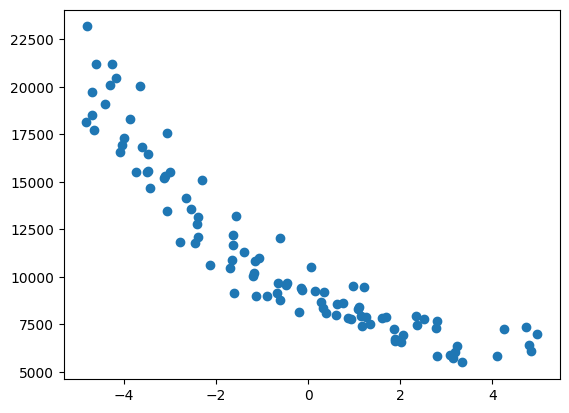

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Generate a matrix
A = np.random.uniform(-5, 5, (100, 5))

rf_sea_pred = rf_sea.predict(A)

plt.scatter(A[:,4], rf_sea_pred)



## XGboost

In [4]:
# packages
import pandas as pd
import xgboost as xgb
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score


In [7]:
## p2 ##

dsets = list(range(43, 54))
size = 250

metrics = {
    "Intrusion": {
        "MSE": [],
        "r-squared": []
    },
    "Mass": {
        "MSE": [],
        "r-squared": []
    }
}

for dset in dsets:
    # load data
    data = pd.read_csv(f"data_p2/{size}D/{size}d5_p2_seed_{dset}.csv")
    X = data[['x0', 'x1', 'x2', 'x3', 'x4']]
    y_intrusion = data['Intrusion']
    y_mass = data['Mass']
    y_penalized_mass = data['Penalized Mass']


    # train test split
    # TODO: set up folds with diff seeds
    X_intrusion_train, X_intrusion_test, y_intrusion_train, y_intrusion_test = train_test_split(X, y_intrusion, test_size=0.2, random_state=dset)
    X_mass_train, X_mass_test, y_mass_train, y_mass_test = train_test_split(X, y_mass, test_size=0.2, random_state=dset)
    X_penalized_mass_train,X_penalized_mass_test,y_penalized_mass_train, y_penalized_mass_test = train_test_split(X, y_penalized_mass, test_size=0.2, random_state=dset)

    # initialize models
    xgb_intrusion = xgb.XGBRegressor(
        n_estimators = 100,
        max_depth=5,
        random_state=dset,
        learning_rate=0.1
    )

    xgb_mass = xgb.XGBRegressor(
        n_estimators = 100,
        max_depth=5,
        random_state=dset,
        learning_rate=0.1
    )

    xgb_penalized_mass = xgb.XGBRegressor(
        n_estimators = 100,
        max_depth=5,
        random_state=dset,
        learning_rate=0.1
    )

    # fit models
    xgb_intrusion.fit(X_intrusion_train, y_intrusion_train)
    xgb_mass.fit(X_mass_train, y_mass_train)
    xgb_penalized_mass.fit(X_penalized_mass_train, y_penalized_mass_train)

    # run predictions and evaluate
    xgb_intrusion_predictions = xgb_intrusion.predict(X_intrusion_test)
    xgb_mass_predictions = xgb_mass.predict(X_mass_test)
    xgb_penalized_mass_predictions = xgb_penalized_mass.predict(X_penalized_mass_test)

    mse_intrusion = mean_squared_error(y_intrusion_test, xgb_intrusion_predictions)
    r2_intrusion = r2_score(y_intrusion_test, xgb_intrusion_predictions)
    mse_mass = mean_squared_error(y_mass_test,xgb_mass_predictions)
    r2_mass = r2_score(y_mass_test, xgb_mass_predictions)
    mse_penalized_mass = mean_squared_error(y_penalized_mass_test, xgb_penalized_mass_predictions)
    r2_penalized_mass = r2_score(y_penalized_mass_test, xgb_penalized_mass_predictions)

    metrics['Intrusion']["MSE"].append(mse_intrusion)
    metrics['Intrusion']["r-squared"].append(r2_intrusion)
    metrics['Mass']["MSE"].append(mse_mass)
    metrics['Mass']["r-squared"].append(r2_mass)


    # print("=== XGBoost on problem 2 - threepointbending ===")
    # print(f"Inrusion | MSE: {mse_intrusion}   r-squared: {r2_intrusion}")
    # print(f"Mass | MSE: {mse_mass}   r-squared: {r2_mass}")
    # print(f"Penalized Mass | MSE: {mse_penalized_mass}   r-squared: {r2_penalized_mass}")


#TODO: save metrics to csv for analysis
print(f"====================== XGBoost on problem 2 (threepointbending) with {len(dsets)} cv folds ======================")
print(f"Intrusion | mean MSE: {np.mean(metrics['Intrusion']['MSE'])}   mean r-squared: {np.mean(metrics['Intrusion']['r-squared'])}")
print(f"Mass | mean MSE: {np.mean(metrics['Mass']['MSE'])}   mean r-squared: {np.mean(metrics['Mass']['r-squared'])}")


====================== XGBoost on problem 2 (threepointbending) with 11 cv folds ======================
Intrusion | mean MSE: 0.33954025468902865   mean r-squared: 0.9658195935010055
Mass | mean MSE: 0.0023416838470473665   mean r-squared: 0.970728110006499


In [13]:
## p1 ##

dsets = list(range(43, 53)) # exclud 53 since it makes an issue with dset size
size = 250

metrics = {
    "Intrusion": {
        "MSE": [],
        "r-squared": []
    },
    "SEA": {
        "MSE": [],
        "r-squared": []
    }
}

for dset in dsets:
    # load data
    data = pd.read_csv(f"data_p1/{size}D/{size}d5_p1_seed_{dset}.csv")
    # load data
    # data = pd.read_csv("250d5_p1_seed_43.csv")
    X = data[['x0', 'x1', 'x2', 'x3', 'x4']]
    y_intrusion = data['Intrusion']
    y_sea = data['SEA']
    y_penalized_sea = data['Penalized SEA']


    # train test split
    # TODO: set up folds with diff seeds
    X_intrusion_train, X_intrusion_test, y_intrusion_train, y_intrusion_test = train_test_split(X, y_intrusion, test_size=0.2, random_state=dset)
    X_sea_train, X_sea_test, y_sea_train, y_sea_test = train_test_split(X, y_sea, test_size=0.2, random_state=dset)
    X_penalized_sea_train,X_penalized_sea_test,y_penalized_sea_train, y_penalized_sea_test = train_test_split(X, y_penalized_sea, test_size=0.2, random_state=dset)

    # initialize models
    xgb_intrusion = xgb.XGBRegressor(
        n_estimators = 275,
        max_depth=5,
        random_state=dset,
        learning_rate=0.1
    )

    xgb_sea = xgb.XGBRegressor(
        n_estimators = 275,
        max_depth=5,
        random_state=dset,
        learning_rate=0.1
    )

    xgb_penalized_sea = xgb.XGBRegressor(
        n_estimators = 275,
        max_depth=5,
        random_state=dset,
        learning_rate=0.1
    )

    # fit models
    print(f"fitting for seed {dset}")
    xgb_intrusion.fit(X_intrusion_train, y_intrusion_train)
    xgb_sea.fit(X_sea_train, y_sea_train)
    xgb_penalized_sea.fit(X_penalized_sea_train, y_penalized_sea_train)

    # run predictions and evaluate
    xgb_intrusion_predictions = xgb_intrusion.predict(X_intrusion_test)
    xgb_sea_predictions = xgb_sea.predict(X_sea_test)
    xgb_penalized_sea_predictions = xgb_penalized_sea.predict(X_penalized_sea_test)

    mse_intrusion = mean_squared_error(y_intrusion_test, xgb_intrusion_predictions)
    r2_intrusion = r2_score(y_intrusion_test, xgb_intrusion_predictions)
    mse_sea = mean_squared_error(y_sea_test,xgb_sea_predictions)
    r2_sea = r2_score(y_sea_test, xgb_sea_predictions)
    mse_penalized_sea = mean_squared_error(y_penalized_sea_test, xgb_penalized_sea_predictions)
    r2_penalized_sea = r2_score(y_penalized_sea_test, xgb_penalized_sea_predictions)

    metrics['Intrusion']["MSE"].append(mse_intrusion)
    metrics['Intrusion']["r-squared"].append(r2_intrusion)
    metrics['SEA']["MSE"].append(mse_mass)
    metrics['SEA']["r-squared"].append(r2_mass)

    # print("=== XGBoost on problem 1 - starbox ===")
    # print(f"Inrusion | MSE: {mse_intrusion}   r-squared: {r2_intrusion}")
    # print(f"SEA | MSE: {mse_sea}   r-squared: {r2_sea}")
    # print(f"Penalized SEA | MSE: {mse_penalized_sea}   r-squared: {r2_penalized_sea}")

#TODO: save metrics to csv for analysis
print(f"====================== XGBoost on problem 1 (threepointbending) with {len(dsets)} cv folds ======================")
print(f"Intrusion | mean MSE: {np.mean(metrics['Intrusion']['MSE'])}   mean r-squared: {np.mean(metrics['Intrusion']['r-squared'])}")
print(f"SEA | mean MSE: {np.mean(metrics['SEA']['MSE'])}   mean r-squared: {np.mean(metrics['SEA']['r-squared'])}")

fitting for seed 43
fitting for seed 44
fitting for seed 45
fitting for seed 46
fitting for seed 47
fitting for seed 48
fitting for seed 49
fitting for seed 50
fitting for seed 51
fitting for seed 52
====================== XGBoost on problem 1 (threepointbending) with 10 cv folds ======================
Intrusion | mean MSE: 4.338384855091075   mean r-squared: 0.9946133243384413
SEA | mean MSE: 0.002536588881212241   mean r-squared: 0.9708247695173288


In [ ]:
## p3 ##

# load data 
data = pd.read_csv("125d15_p3.csv")
X = data[['x0', 'x1', 'x2', 'x3', 'x4','x5','x6','x7','x8','x9','x10','x11','x12','x13', 'x14']]
y_intrusion = data['Intrusion']
y_lu = data['LU']

X_intrusion_train, X_intrusion_test, y_intrusion_train, y_intrusion_test = train_test_split(X, y_intrusion, test_size=0.2, random_state=1)
X_lu_train, X_lu_test, y_lu_train, y_lu_test = train_test_split(X, y_lu, test_size=0.2, random_state=1)

xgb_lu = xgb.XGBRegressor(
    n_estimators = 275,
    max_depth=5,
    random_state=1,
    learning_rate=0.1
)

xgb_lu.fit(X_lu_train, y_lu_train)

xgb_lu_predictions = xgb_lu.predict(X_lu_test)

lu_mse = mean_squared_error(y_lu_test, xgb_lu_predictions)
lu_r2 = r2_score(y_lu_test, y_lu_test, xgb_lu_predictions)

print("=== XGBoost on problem 3 - crashtube ===")
print(f"LU | MSE: {lu_mse}   r-squared: {lu_r2}")

## RSM

In [41]:
# packages
import pandas as pd
from pyDOE3 import ccdesign
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
## p2 ##

dsets = list(range(43, 54)) 
size = 250

metrics = {
    "Intrusion": {
        "MSE": [],
        "r-squared": []
    },
    "Mass": {
        "MSE": [],
        "r-squared": []
    }
}

for dset in dsets:
    # load data
    data = pd.read_csv(f"data_p2/{size}D/{size}d5_p2_seed_{dset}.csv")
    X = data[['x0', 'x1', 'x2', 'x3', 'x4']]
    y_intrusion = data['Intrusion']
    y_mass = data['Mass']
    y_penalized_mass = data['Penalized Mass']

    X_scaled = 2*(X-X.min()/(X.max()-X.min()))-1 # -> minmax scaler

    X_intrusion_train, X_intrusion_test, y_intrusion_train, y_intrusion_test = train_test_split(X, y_intrusion, test_size=0.2, random_state=dset)
    X_mass_train, X_mass_test, y_mass_train, y_mass_test = train_test_split(X, y_mass, test_size=0.2, random_state=dset)
    X_penalized_mass_train, X_penalized_mass_test, y_penalized_mass_train, y_penalized_mass_test = train_test_split(X, y_penalized_mass, test_size=0.2, random_state=dset)

    # define the things

    # design = ccdesign(5, alpha='o', face='ccf')


    polynomial_features = PolynomialFeatures(degree=2)
    X_pf = polynomial_features.fit_transform(X_scaled)

    X_intrusion_train_poly = polynomial_features.fit_transform(X_intrusion_train)
    X_intrusion_test_poly = polynomial_features.transform(X_intrusion_test)
    X_mass_train_poly = polynomial_features.fit_transform(X_mass_train)
    X_mass_test_poly = polynomial_features.transform(X_mass_test)
    X_penalized_mass_train_poly = polynomial_features.fit_transform(X_penalized_mass_train)
    X_penalized_mass_test_poly = polynomial_features.transform(X_penalized_mass_test)

    rsm_intrusion = LinearRegression()
    rsm_mass = LinearRegression()
    rsm_penalized_mass = LinearRegression()

    print(f"fitting on set {dset}")

    rsm_intrusion.fit(X_intrusion_train_poly, y_intrusion_train)
    rsm_mass.fit(X_mass_train_poly,y_mass_train)
    rsm_penalized_mass.fit(X_penalized_mass_train_poly, y_penalized_mass_train)

    rsm_intrusion_predictions = rsm_intrusion.predict(X_intrusion_test_poly)
    rsm_mass_predictions = rsm_mass.predict(X_mass_test_poly)
    rsm_penalized_mass_predictions = rsm_penalized_mass.predict(X_penalized_mass_test_poly)

    mse_intrusion = mean_squared_error(y_intrusion_test, rsm_intrusion_predictions)
    r2_intrusion = r2_score(y_intrusion_test, rsm_intrusion_predictions)
    mse_mass = mean_squared_error(y_mass_test, rsm_mass_predictions)
    r2_mass = r2_score(y_mass_test, rsm_mass_predictions)
    mse_penalized_mass = mean_squared_error(y_penalized_mass_test, rsm_penalized_mass_predictions)
    r2_penalized_mass = r2_score(y_penalized_mass_test, rsm_penalized_mass_predictions)

    # print("=== Response Surface Model on problem 2 - threepointbending ===")
    # print(f"Intrusion | MSE: {mse_intrusion}   r-squared: {r2_intrusion}")
    # print(f"Mass | MSE: {mse_mass}   r-squared: {r2_mass}")
    # print(f"Penalized Mass | MSE: {mse_penalized_mass}   r-squared: {r2_penalized_mass}")

    #TODO: save metrics to csv for analysis
    metrics['Intrusion']["MSE"].append(mse_intrusion)
    metrics['Intrusion']["r-squared"].append(r2_intrusion)
    metrics['Mass']["MSE"].append(mse_mass)
    metrics['Mass']["r-squared"].append(r2_mass)
    
print(f"====================== Respnse Surface Methodology on problem 2 (threepointbending) with {len(dsets)} cv folds ======================")
print(f"Intrusion | mean MSE: {np.mean(metrics['Intrusion']['MSE'])}   mean r-squared: {np.mean(metrics['Intrusion']['r-squared'])}")
print(f"Mass | mean MSE: {np.mean(metrics['Mass']['MSE'])}   mean r-squared: {np.mean(metrics['Mass']['r-squared'])}")


fitting on set 43
fitting on set 44
fitting on set 45
fitting on set 46
fitting on set 47
fitting on set 48
fitting on set 49
fitting on set 50
fitting on set 51
fitting on set 52
fitting on set 53
====================== Respnse Surface Methodology on problem 2 (threepointbending) with 11 cv folds ======================
Intrusion | mean MSE: 0.03106115480878371   mean r-squared: 0.9969091638307311
Mass | mean MSE: 1.224888690186779e-12   mean r-squared: 0.9999999999846341


In [46]:
## p1 ##

dsets = list(range(43, 53)) # exclud 53 since it makes an issue with dset size
size = 250

metrics = {
    "Intrusion": {
        "MSE": [],
        "r-squared": []
    },
    "SEA": {
        "MSE": [],
        "r-squared": []
    }
}

for dset in dsets:

    # load data
    data = pd.read_csv(f"data_p1/{size}D/{size}d5_p1_seed_{dset}.csv")
    X = data[['x0', 'x1', 'x2', 'x3', 'x4']]
    y_intrusion = data['Intrusion']
    y_sea = data['SEA']
    y_penalized_sea= data['Penalized SEA']

    X_scaled = 2*(X-X.min()/(X.max()-X.min()))-1 # -> MinMaScaler(featurerange=); X_scaled = scaler.fit_transform(X)

    X_intrusion_train, X_intrusion_test, y_intrusion_train, y_intrusion_test = train_test_split(X, y_intrusion, test_size=0.2, random_state=dset)
    X_sea_train, X_sea_test, y_sea_train, y_sea_test = train_test_split(X, y_sea, test_size=0.2, random_state=dset)
    X_penalized_sea_train, X_penalized_sea_test, y_penalized_sea_train, y_penalized_sea_test = train_test_split(X, y_penalized_sea, test_size=0.2, random_state=dset)

    # define the things

    # design = ccdesign(5, alpha='o', face='ccf')


    polynomial_features = PolynomialFeatures(degree=2)
    X_pf = polynomial_features.fit_transform(X_scaled)

    X_intrusion_train_poly = polynomial_features.fit_transform(X_intrusion_train)
    X_intrusion_test_poly = polynomial_features.transform(X_intrusion_test)
    X_sea_train_poly = polynomial_features.fit_transform(X_sea_train)
    X_sea_test_poly = polynomial_features.transform(X_sea_test)
    X_penalized_sea_train_poly = polynomial_features.fit_transform(X_penalized_sea_train)
    X_penalized_sea_test_poly = polynomial_features.transform(X_penalized_sea_test)

    rsm_intrusion = LinearRegression()
    rsm_sea = LinearRegression()
    rsm_penalized_sea = LinearRegression()

    print(f"fitting on set {dset}")

    rsm_intrusion.fit(X_intrusion_train_poly, y_intrusion_train)
    rsm_sea.fit(X_sea_train_poly,y_sea_train)
    rsm_penalized_sea.fit(X_penalized_sea_train_poly, y_penalized_sea_train)

    rsm_intrusion_predictions = rsm_intrusion.predict(X_intrusion_test_poly)
    rsm_sea_predictions = rsm_sea.predict(X_sea_test_poly)
    rsm_penalized_sea_predictions = rsm_penalized_sea.predict(X_penalized_sea_test_poly)

    mse_intrusion = mean_squared_error(y_intrusion_test, rsm_intrusion_predictions)
    r2_intrusion = r2_score(y_intrusion_test, rsm_intrusion_predictions)
    mse_sea = mean_squared_error(y_sea_test, rsm_sea_predictions)
    r2_sea = r2_score(y_sea_test, rsm_sea_predictions)
    mse_penalized_sea = mean_squared_error(y_penalized_sea_test, rsm_penalized_sea_predictions)
    r2_penalized_sea = r2_score(y_penalized_sea_test, rsm_penalized_sea_predictions)

    # print("=== Response Surface Model on problem 2 - threepointbending ===")
    # print(f"Intrusion | MSE: {mse_intrusion}   r-squared: {r2_intrusion}")
    # print(f"SEA| MSE: {mse_sea}   r-squared: {r2_sea}")
    # print(f"Penalized SEA| MSE: {mse_penalized_sea}   r-squared: {r2_penalized_sea}")
    metrics['Intrusion']["MSE"].append(mse_intrusion)
    metrics['Intrusion']["r-squared"].append(r2_intrusion)
    metrics['SEA']["MSE"].append(mse_mass)
    metrics['SEA']["r-squared"].append(r2_mass)
    
print(f"====================== Respnse Surface Methodology on problem 1 (starbox) with {len(dsets)} cv folds ======================")
print(f"Intrusion | mean MSE: {np.mean(metrics['Intrusion']['MSE'])}   mean r-squared: {np.mean(metrics['Intrusion']['r-squared'])}")
print(f"SEA | mean MSE: {np.mean(metrics['SEA']['MSE'])}   mean r-squared: {np.mean(metrics['SEA']['r-squared'])}")


fitting on set 43
fitting on set 44
fitting on set 45
fitting on set 46
fitting on set 47
fitting on set 48
fitting on set 49
fitting on set 50
fitting on set 51
fitting on set 52
====================== Respnse Surface Methodology on problem 1 (starbox) with 10 cv folds ======================
Intrusion | mean MSE: 19.60312749489672   mean r-squared: 0.9757013295498206
SEA | mean MSE: 1.1254054424084295e-12   mean r-squared: 0.9999999999870559


In [1]:
# version test
import pgmpy
import pgmpy.estimators as est
print(est.__file__)
print(pgmpy.__version__)
print([x for x in dir(est) if "Gauss" in x])

/home/odysseas/miniconda3/envs/conda_mechbench/lib/python3.14/site-packages/pgmpy/estimators/__init__.py
1.1.2
['AICCondGauss', 'AICGauss', 'BICCondGauss', 'BICGauss', 'LogLikelihoodCondGauss', 'LogLikelihoodGauss']


/home/odysseas/miniconda3/envs/conda_mechbench/lib/python3.14/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (
